# 🎸 Queen Discography Analytics  (v3)

| Cell | Purpose |
|------|--------|
| 1 | Install deps |
| 2 | Imports & colour map |
| 3 | Load, clean, parse — creates full & filtered datasets |
| 4 | Chart 1: Album ratings (album / mean song / best song) |
| 5 | Chart 2: Song distributions per album |
| 6 | Chart 3: Top 20 & Bottom 10 |
| 7 | Chart 4: Songwriter leaderboard |
| 8 | Chart 5: Songwriter contributions per album |
| 9 | Chart 6: Songwriter trends |
| 10 | Chart 7: Heatmap |
| 11 | Spotify popularity |
| 12 | HTML export with sticky Flash/Cosmos toggle |

Every chart has an **⚡ Exclude Flash/Cosmos** button. The HTML report has a single sticky toggle that controls all charts at once.

In [13]:
# Queen Discography Analytics — v3
import subprocess, sys
r = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'plotly', 'pandas', 'spotipy', 'tqdm', '-q'],
    capture_output=True, text=True
)
print("\u2713 Dependencies ready" if r.returncode == 0 else r.stderr[:400])


✓ Dependencies ready


In [14]:
from plotly.io import to_html
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import os, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 60)

WRITER_COLOURS = {
    'Mercury':           '#E8A838',
    'May':               '#4A90E2',
    'Deacon':            '#5CB85C',
    'Taylor':            '#C0392B',
    'Queen':             '#9B59B6',
    'Other/Collective':  '#7F8C8D',
    'Queen/Rogers':      '#16A085',
    'Collaboration':     '#2C3E50',
    'Traditional':       '#BDC3C7',
}
MAIN_WRITERS = ['Mercury', 'May', 'Deacon', 'Taylor']
PALETTE = px.colors.qualitative.Set2 + px.colors.qualitative.Pastel1
EXCLUDE_ALBUMS = ['Flash Gordon', 'The Cosmos Rocks']
BTN_STYLE = dict(bgcolor='#21262d', bordercolor='#58a6ff', font=dict(color='white', size=11))

SINGLES = {
    'Keep Yourself Alive', 'Seven Seas of Rhye', 'Killer Queen',
    "Now I'm Here", 'Bohemian Rhapsody', "You're My Best Friend",
    'Somebody to Love', 'Tie Your Mother Down', 'Good Old-Fashioned Lover Boy',
    'We Are the Champions', 'We Will Rock You', 'Spread Your Wings',
    'Bicycle Race', 'Fat Bottomed Girls', "Don't Stop Me Now",
    'Crazy Little Thing Called Love', 'Save Me', 'Play the Game',
    'Another One Bites the Dust', 'Need Your Loving Tonight', 'Flash',
    'Under Pressure', 'Body Language', 'Las Palabras de Amor (The Words of Love)',
    'Back Chat', 'Radio Ga Ga', 'I Want to Break Free', "It's a Hard Life",
    'Hammer to Fall', 'Man on the Prowl', 'One Vision', 'A Kind of Magic',
    'Friends Will Be Friends', 'Who Wants to Live Forever', 'Pain Is So Close to Pleasure',
    'One Year of Love', 'I Want It All', 'Breakthru', 'The Invisible Man',
    'Scandal', 'The Miracle', 'Innuendo', "I'm Going Slightly Mad",
    'Headlong', 'The Show Must Go On', 'These Are the Days of Our Lives',
    'Heaven for Everyone', "A Winter's Tale", 'Too Much Love Will Kill You',
    'Let Me Live', 'Made in Heaven', "You Don't Fool Me", "Say It's Not True", "C-Lebrity",
}

print("\u2713 Imports OK")

✓ Imports OK


## 🧹 Load & Clean

In [15]:
# ── Load & Clean ──────────────────────────────────────────────────────────────
DATA_FILE = 'queen_ratings_base.csv'
df_raw = pd.read_csv(DATA_FILE, encoding='latin-1')


df = df_raw.copy()
df['Year']   = pd.to_numeric(df['Year'],   errors='coerce')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Year']   = df['Year'].ffill().astype(int)

df_albums = df[df['Song'].isna()  | (df['Song'].astype(str).str.strip() == '')].copy()
df_songs  = df[df['Song'].notna() & (df['Song'].astype(str).str.strip() != '')].copy()
album_order = df_albums.sort_values('Year')['Album'].tolist()

def primary_writer(s):
    if pd.isna(s) or str(s).strip() == '': return 'Unknown'
    s = str(s).strip()
    if '[' in s:
        inner = s[s.index('[')+1:s.index(']')]
        return inner.split('/')[0].strip()
    if s.startswith('Queen/Rogers'): return 'Queen/Rogers'
    if s.startswith('Queen/Bowie'):  return 'Collaboration'
    if s.startswith('Traditional'):  return 'Traditional'
    if s.startswith('Queen'):        return 'Queen'
    return s.split('/')[0].strip()

def main_writer(s):
    pw = primary_writer(s)
    return pw if pw in {'Mercury','May','Deacon','Taylor'} else 'Other/Collective'

df_songs['primary_writer'] = df_songs['Songwriter'].apply(primary_writer)
df_songs['main_writer']    = df_songs['Songwriter'].apply(main_writer)
df_songs['track_number']   = df_songs.groupby('Album').cumcount() + 1
df_songs['album_rank']     = df_songs['Album'].map({a: i for i, a in enumerate(album_order)})
df_albums['album_rank']    = range(len(df_albums))
df_songs  = df_songs.sort_values(['album_rank', 'track_number']).reset_index(drop=True)
df_albums = df_albums.sort_values('album_rank').reset_index(drop=True)

# ── Filtered datasets ─────────────────────────────────────────────────────────
df_songs_filt    = df_songs[~df_songs['Album'].isin(EXCLUDE_ALBUMS)].copy()
df_albums_filt   = df_albums[~df_albums['Album'].isin(EXCLUDE_ALBUMS)].copy()
album_order_filt = [a for a in album_order if a not in EXCLUDE_ALBUMS]

# ── Singles tag ───────────────────────────────────────────────────────────────
df_songs['is_single']      = df_songs['Song'].isin(SINGLES)
df_songs_filt['is_single'] = df_songs_filt['Song'].isin(SINGLES)
print(f"Singles in full dataset     : {df_songs['is_single'].sum()}")
print(f"Singles in filtered dataset : {df_songs_filt['is_single'].sum()}")

# ── Summary ───────────────────────────────────────────────────────────────────
best  = df_songs.loc[df_songs['Rating'].idxmax()]
worst = df_songs.loc[df_songs['Rating'].idxmin()]
print(f"{'='*56}")
print(f"  Queen Discography \u2014 RYM Rating Data")
print(f"{'='*56}")
print(f"  Albums (all / filtered)   : {len(df_albums)} / {len(df_albums_filt)}")
print(f"  Songs  (all / filtered)   : {len(df_songs)} / {len(df_songs_filt)}")
print(f"  Mean song rating (all)    : {df_songs['Rating'].mean():.3f} / 5.0")
print(f"  Mean song rating (filt.)  : {df_songs_filt['Rating'].mean():.3f} / 5.0")
print(f"  Highest rated             : {best['Song']}  ({best['Rating']:.2f})")
print(f"  Lowest rated              : {worst['Song']}  ({worst['Rating']:.2f})")
print(f"{'='*56}")

Singles in full dataset     : 54
Singles in filtered dataset : 51
  Queen Discography — RYM Rating Data
  Albums (all / filtered)   : 16 / 14
  Songs  (all / filtered)   : 183 / 151
  Mean song rating (all)    : 3.453 / 5.0
  Mean song rating (filt.)  : 3.607 / 5.0
  Highest rated             : Bohemian Rhapsody  (4.63)
  Lowest rated              : The Ring (Hypnotic Seduction of Dale)  (2.13)


## 📊 Chart 1 — Album Ratings

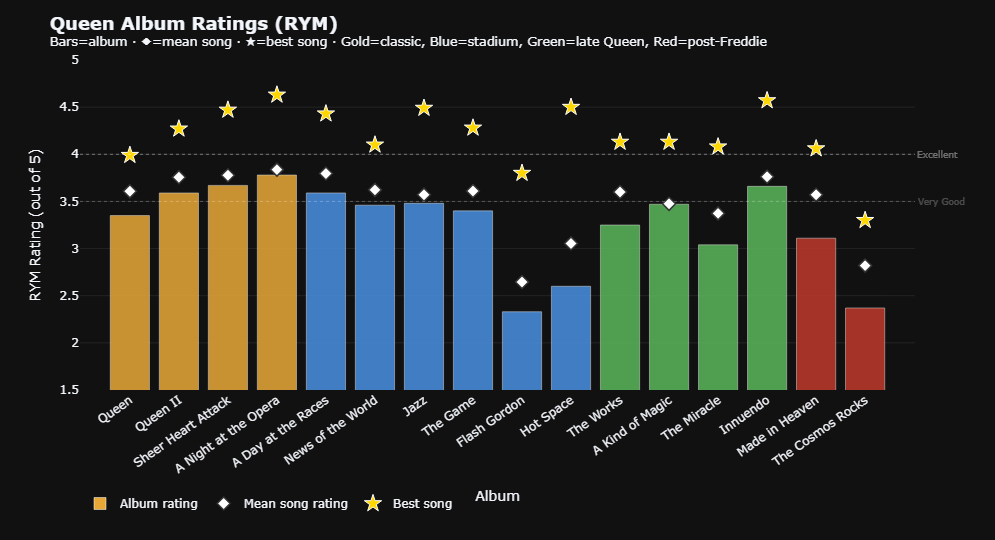

In [16]:
# ── Chart 1: Album Ratings Timeline ──────────────────────────────────────────
def era_colour(year):
    if year <= 1975: return '#E8A838'
    if year <= 1982: return '#4A90E2'
    if year <= 1991: return '#5CB85C'
    return '#C0392B'

def album_stats(df_s, df_a):
    means = df_s.groupby('Album')['Rating'].mean().reset_index()
    means.columns = ['Album','mean_rating']
    bests = (df_s.sort_values('Rating', ascending=False)
             .groupby('Album', as_index=False).first()
             [['Album','Song','Rating']]
             .rename(columns={'Song':'best_song','Rating':'best_rating'}))
    alb = df_a.merge(means, on='Album').merge(bests, on='Album')
    alb['colour'] = alb['Year'].apply(era_colour)
    return alb.sort_values('album_rank')

def c1_traces(df_s, df_a, show):
    alb = album_stats(df_s, df_a)
    return [
        go.Bar(
            x=alb['Album'], y=alb['Rating'], name='Album rating',
            visible=show, showlegend=True, legendgroup='albumrating',
            marker=dict(color=alb['colour'].tolist(), opacity=0.85,
                        line=dict(color='white', width=0.5)),
            customdata=alb[['Album','Year','Rating','mean_rating']].values,
            hovertemplate=(
                '<b>%{customdata[0]}</b> (%{customdata[1]})<br>'
                'Album rating: <b>%{customdata[2]:.2f}</b><br>'
                'Mean song: %{customdata[3]:.2f}<extra></extra>'
            )
        ),
        go.Scatter(
            x=alb['Album'], y=alb['mean_rating'],
            mode='markers', name='Mean song rating',
            visible=show, showlegend=True, legendgroup='meansong',
            marker=dict(symbol='diamond', size=10, color='white',
                        line=dict(width=1.5, color='#333')),
            customdata=alb[['Album','mean_rating']].values,
            hovertemplate='<b>%{customdata[0]}</b><br>Mean: <b>%{customdata[1]:.2f}</b><extra></extra>'
        ),
        go.Scatter(
            x=alb['Album'], y=alb['best_rating'],
            mode='markers', name='Best song',
            visible=show, showlegend=True, legendgroup='bestsong',
            marker=dict(symbol='star', size=13, color='#FFD700',
                        line=dict(width=1, color='white')),
            customdata=alb[['Album','best_song','best_rating']].values,
            hovertemplate=(
                '<b>%{customdata[0]}</b><br>'
                'Best: <b>%{customdata[1]}</b><br>'
                'Rating: %{customdata[2]:.2f}<extra></extra>'
            )
        ),
    ]

N_C1 = 3
fig1 = go.Figure()
for t in c1_traces(df_songs,      df_albums,      True):  fig1.add_trace(t)
for t in c1_traces(df_songs_filt, df_albums_filt, False): fig1.add_trace(t)

for y, label, col in [(3.5,'Very Good','rgba(255,255,255,0.25)'),
                      (4.0,'Excellent','rgba(255,255,255,0.4)')]:
    fig1.add_hline(y=y, line=dict(color=col, dash='dot', width=1),
        annotation_text=label, annotation_font=dict(color=col, size=9),
        annotation_position='right')

fig1.update_layout(
    title=dict(text='<b>Queen Album Ratings (RYM)</b><br>'
               '<sup>Bars=album \u00b7 \u25c6=mean song \u00b7 \u2605=best song \u00b7 Gold=classic, Blue=stadium, Green=late Queen, Red=post-Freddie</sup>',
               font_size=18),
    xaxis=dict(title='Album', tickangle=-35),
    yaxis=dict(title='RYM Rating (out of 5)', range=[1.5, 5.0],
               gridcolor='rgba(255,255,255,0.08)'),
    template='plotly_dark', height=540,
    legend=dict(orientation='h', x=0, y=-0.3),
    margin=dict(t=60, b=150),
)
fig1.show()


## 📦 Chart 2 — Song Distributions

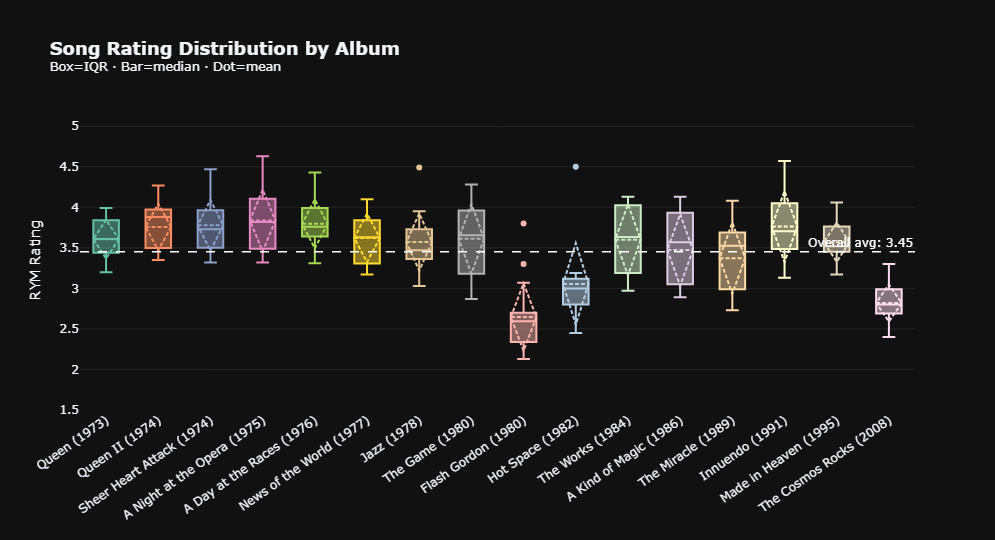

In [17]:
# ── Chart 2: Song Rating Distribution per Album ───────────────────────────────
def c2_traces(df_s, df_a, ao, show):
    traces = []
    for i, album in enumerate(ao):
        s   = df_s[df_s['Album'] == album]
        col = PALETTE[i % len(PALETTE)]
        yr  = df_a.loc[df_a['Album'] == album, 'Year'].values[0]
        traces.append(go.Box(
            y=s['Rating'], name=f'{album} ({yr})',
            visible=show, showlegend=False,
            marker_color=col, boxmean='sd',
            customdata=s[['Song','Songwriter','Rating']].values,
            hovertemplate='<b>%{customdata[0]}</b><br>%{customdata[1]}<br>Rating: %{customdata[2]:.2f}<extra></extra>'
        ))
    return traces

N_C2  = len(album_order)
N_C2F = len(album_order_filt)
fig2  = go.Figure()
for t in c2_traces(df_songs,      df_albums,      album_order,      True):  fig2.add_trace(t)
for t in c2_traces(df_songs_filt, df_albums_filt, album_order_filt, False): fig2.add_trace(t)

fig2.add_hline(y=df_songs['Rating'].mean(),
    line=dict(color='white', dash='dash', width=1.5),
    annotation_text=f'Overall avg: {df_songs["Rating"].mean():.2f}',
    annotation_font_color='white')

fig2.update_layout(
    title=dict(text='<b>Song Rating Distribution by Album</b><br>'
               '<sup>Box=IQR \u00b7 Bar=median \u00b7 Dot=mean</sup>', font_size=18),
    xaxis=dict(tickangle=-35),
    yaxis=dict(title='RYM Rating', range=[1.5,5.2],
               gridcolor='rgba(255,255,255,0.08)'),
    template='plotly_dark', height=540, showlegend=False,
    margin=dict(t=110, b=130),

)
fig2.show()


## 🥇 Chart 3 — Top 20 & Bottom 10

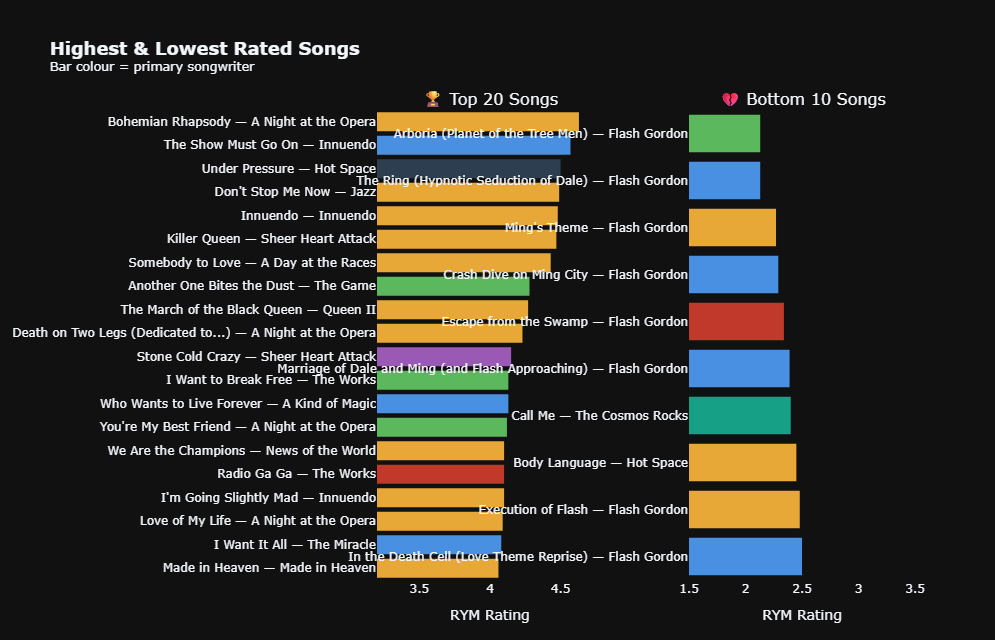

In [18]:
# ── Chart 3: Top 20 & Bottom 10 Songs ────────────────────────────────────────
def bar_colours(sub):
    return [WRITER_COLOURS.get(w,'#888') for w in sub['primary_writer']]

def c3_traces(df_s, show):
    top = df_s.nlargest(20,'Rating').sort_values('Rating')
    bot = df_s.nsmallest(10,'Rating').sort_values('Rating', ascending=False)
    return [
        go.Bar(
            y=top['Song'] + ' \u2014 ' + top['Album'],
            x=top['Rating'], orientation='h', name='Top',
            visible=show, showlegend=False,
            marker=dict(color=bar_colours(top), line=dict(width=0)),
            customdata=top[['Songwriter','Album','Rating']].values,
            hovertemplate='<b>%{y}</b><br>Writer: %{customdata[0]}<br>Rating: <b>%{x:.2f}</b><extra></extra>'
        ),
        go.Bar(
            y=bot['Song'] + ' \u2014 ' + bot['Album'],
            x=bot['Rating'], orientation='h', name='Bottom',
            visible=show, showlegend=False,
            marker=dict(color=bar_colours(bot), line=dict(width=0)),
            customdata=bot[['Songwriter','Album','Rating']].values,
            hovertemplate='<b>%{y}</b><br>Writer: %{customdata[0]}<br>Rating: <b>%{x:.2f}</b><extra></extra>'
        ),
    ]

N_C3 = 2
fig3 = make_subplots(rows=1, cols=2,
    subplot_titles=['\U0001f3c6 Top 20 Songs', '\U0001f494 Bottom 10 Songs'],
    horizontal_spacing=0.16)

for i, t in enumerate(c3_traces(df_songs, True)):
    fig3.add_trace(t, row=1, col=i+1)
for i, t in enumerate(c3_traces(df_songs_filt, False)):
    fig3.add_trace(t, row=1, col=i+1)

fig3.update_xaxes(title_text='RYM Rating', range=[3.2,4.8], row=1, col=1)
fig3.update_xaxes(title_text='RYM Rating', range=[1.5,3.5], row=1, col=2)
fig3.update_layout(
    title=dict(text='<b>Highest & Lowest Rated Songs</b><br>'
               '<sup>Bar colour = primary songwriter</sup>', font_size=18),
    template='plotly_dark', height=640, showlegend=False,
    margin=dict(t=110, b=60),
   
)
fig3.show()


## ✍️ Chart 4 — Songwriter Leaderboard

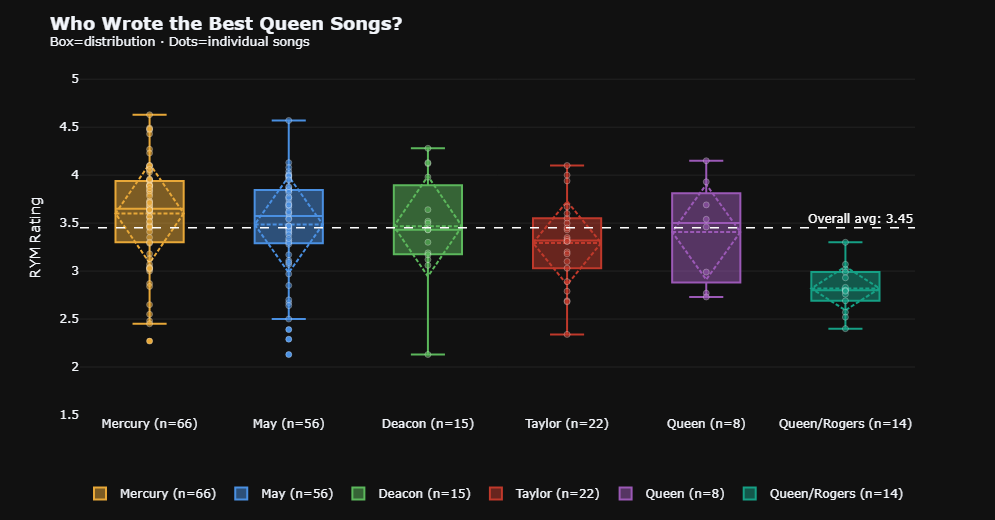

In [19]:
# ── Chart 4: Songwriter Leaderboard ──────────────────────────────────────────
WRITERS_C4 = [w for w in MAIN_WRITERS + ['Queen','Other/Collective','Queen/Rogers']
              if len(df_songs[df_songs['primary_writer'] == w]) >= 2]

def c4_traces(df_s, show):
    traces = []
    for writer in WRITERS_C4:
        sub = df_s[df_s['primary_writer'] == writer]
        col = WRITER_COLOURS.get(writer,'#888')
        lbl = f'{writer} (n={len(sub)})'
        traces.append(go.Box(
            y=sub['Rating'] if not sub.empty else [],
            name=lbl, visible=show,
            showlegend=True, legendgroup=writer,
            marker_color=col, boxmean='sd', hoverinfo='skip'
        ))
        traces.append(go.Scatter(
            x=[lbl]*len(sub), y=sub['Rating'].tolist() if not sub.empty else [],
            mode='markers', visible=show, showlegend=False,
            legendgroup=writer,
            marker=dict(color=col, size=6, opacity=0.6,
                        line=dict(width=0.5, color='white')),
            customdata=sub[['Song','Album','Rating']].values if not sub.empty else [],
            hovertemplate='<b>%{customdata[0]}</b><br>%{customdata[1]}<br>Rating: %{customdata[2]:.2f}<extra></extra>'
        ))
    return traces

N_C4 = len(WRITERS_C4) * 2
fig4 = go.Figure()
for t in c4_traces(df_songs,      True):  fig4.add_trace(t)
for t in c4_traces(df_songs_filt, False): fig4.add_trace(t)

fig4.add_hline(y=df_songs['Rating'].mean(),
    line=dict(color='white', dash='dash', width=1.5),
    annotation_text=f'Overall avg: {df_songs["Rating"].mean():.2f}',
    annotation_font_color='white')

fig4.update_layout(
    title=dict(text='<b>Who Wrote the Best Queen Songs?</b><br>'
               '<sup>Box=distribution \u00b7 Dots=individual songs</sup>', font_size=18),
    yaxis=dict(title='RYM Rating', range=[1.5,5.2],
               gridcolor='rgba(255,255,255,0.08)'),
    template='plotly_dark', height=520,
    legend=dict(orientation='h', y=-0.18, x=0),
    margin=dict(t=60),
)
fig4.show()


## 📚 Chart 5 — Songwriter Contributions

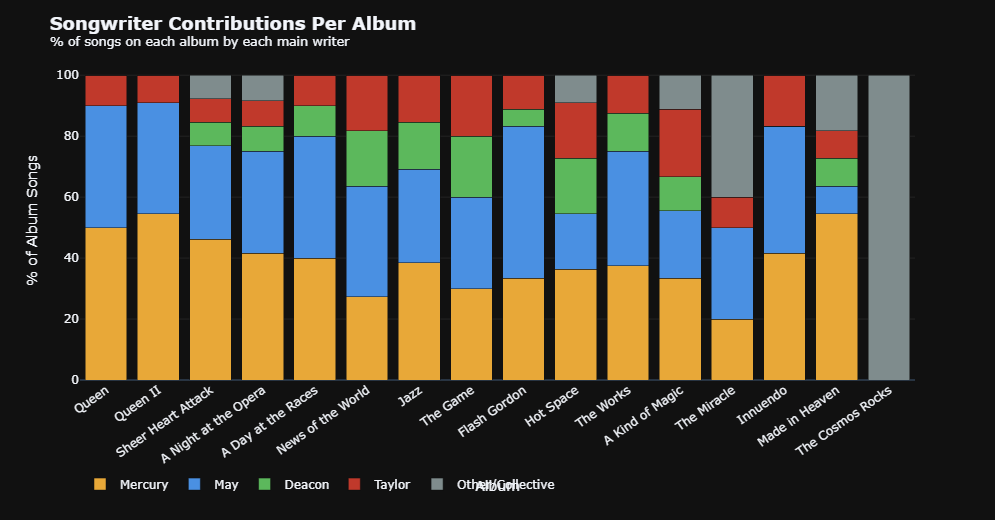

In [20]:
# ── Chart 5: Songwriter Contributions Per Album ───────────────────────────────
def c5_traces(df_s, ao, show):
    contrib = (df_s.groupby(['Album','main_writer'])
               .size().unstack(fill_value=0))
    for w in MAIN_WRITERS + ['Other/Collective']:
        if w not in contrib.columns: contrib[w] = 0
    contrib     = contrib.reindex(ao)
    contrib_pct = contrib.div(contrib.sum(axis=1), axis=0) * 100
    traces = []
    for writer in MAIN_WRITERS + ['Other/Collective']:
        traces.append(go.Bar(
            name=writer, visible=show,
            showlegend=True, legendgroup=writer,
            x=contrib_pct.index, y=contrib_pct[writer],
            marker_color=WRITER_COLOURS.get(writer,'#888'),
            customdata=[[writer, int(contrib.loc[a,writer]),
                         round(contrib_pct.loc[a,writer],1)]
                        for a in contrib_pct.index],
            hovertemplate=(
                '<b>%{x}</b><br>'
                '%{customdata[0]}: <b>%{customdata[1]} songs</b> (%{customdata[2]:.1f}%)<extra></extra>'
            )
        ))
    return traces

N_C5 = 5
fig5 = go.Figure()
for t in c5_traces(df_songs,      album_order,      True):  fig5.add_trace(t)
for t in c5_traces(df_songs_filt, album_order_filt, False): fig5.add_trace(t)

fig5.update_layout(
    barmode='stack',
    title=dict(text='<b>Songwriter Contributions Per Album</b><br>'
               '<sup>% of songs on each album by each main writer</sup>', font_size=18),
    xaxis=dict(title='Album', tickangle=-35),
    yaxis=dict(title='% of Album Songs', range=[0,105],
               gridcolor='rgba(255,255,255,0.08)'),
    template='plotly_dark', height=520,
    legend=dict(orientation='h', y=-0.28, x=0),
    margin=dict(t=60, b=140),
)
fig5.show()


## 📈 Chart 6 — Songwriter Trends

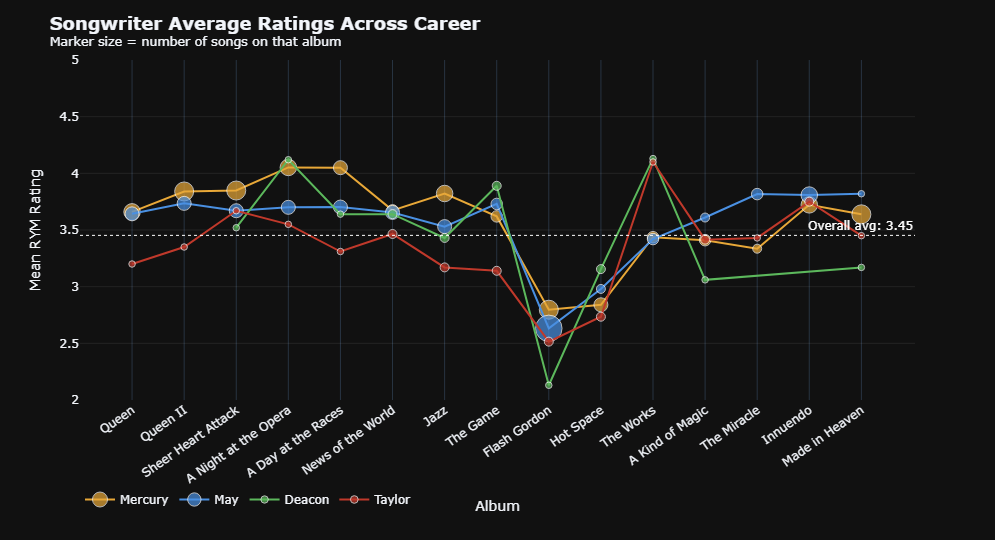

In [21]:
# ── Chart 6: Songwriter Rating Trends Across Career ──────────────────────────
def c6_traces(df_s, ao, show):
    traces = []
    alb_year = df_albums.set_index('Album')['Year'].to_dict()
    alb_rank = {a:i for i,a in enumerate(ao)}
    for writer in MAIN_WRITERS:
        sub = df_s[df_s['main_writer'] == writer]
        per = (sub.groupby('Album')
               .agg(mean_rating=('Rating','mean'), count=('Rating','count'))
               .reset_index())
        per['rank'] = per['Album'].map(alb_rank)
        per['year'] = per['Album'].map(alb_year)
        per = per.dropna(subset=['rank']).sort_values('rank')
        col = WRITER_COLOURS[writer]
        traces.append(go.Scatter(
            x=per['Album'], y=per['mean_rating'],
            mode='lines+markers', name=writer,
            visible=show, showlegend=True, legendgroup=writer,
            line=dict(color=col, width=2),
            marker=dict(size=per['count']*2.5+4, color=col,
                        line=dict(width=1, color='white')),
            customdata=per[['Album','count','mean_rating','year']].values,
            hovertemplate=(
                '<b>%{customdata[0]}</b> (%{customdata[3]})<br>'
                f'{writer}: <b>%{{customdata[2]:.2f}}</b> avg<br>'
                'Songs: %{customdata[1]}<extra></extra>'
            )
        ))
    return traces

N_C6 = len(MAIN_WRITERS)
fig6 = go.Figure()
for t in c6_traces(df_songs,      album_order,      True):  fig6.add_trace(t)
for t in c6_traces(df_songs_filt, album_order_filt, False): fig6.add_trace(t)

fig6.add_hline(y=df_songs['Rating'].mean(),
    line=dict(color='white', dash='dot', width=1),
    annotation_text=f'Overall avg: {df_songs["Rating"].mean():.2f}',
    annotation_font_color='white')

fig6.update_layout(
    title=dict(text='<b>Songwriter Average Ratings Across Career</b><br>'
               '<sup>Marker size = number of songs on that album</sup>', font_size=18),
    xaxis=dict(title='Album', tickangle=-35),
    yaxis=dict(title='Mean RYM Rating', range=[2.0,5.0],
               gridcolor='rgba(255,255,255,0.08)'),
    template='plotly_dark', height=540,
    legend=dict(orientation='h', y=-0.25, x=0),
    margin=dict(t=60, b=140),
)
fig6.show()


## 🔥 Chart 7 — Heatmap

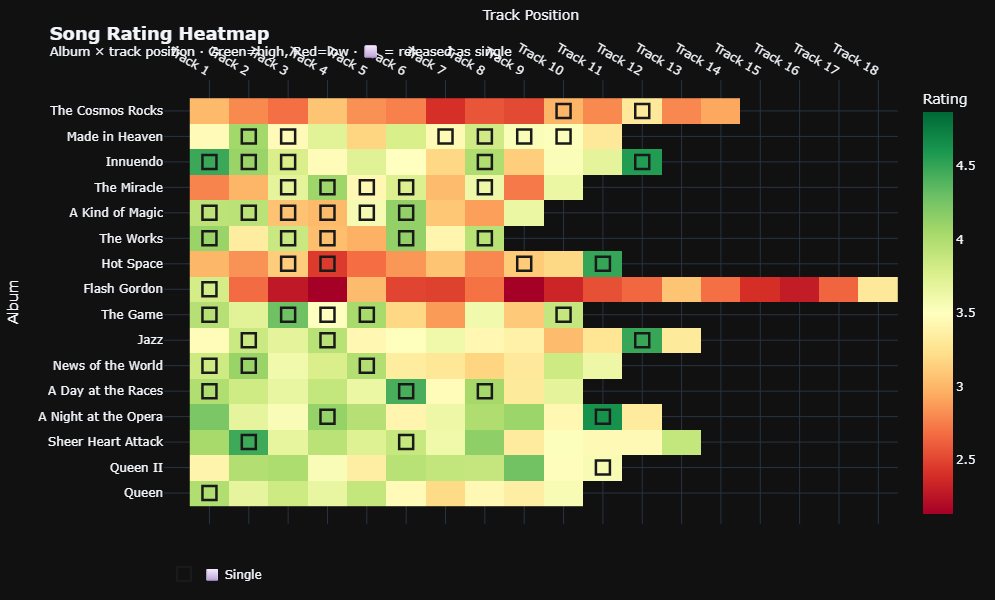

In [22]:
# ── Chart 7: Song Rating Heatmap with Singles highlighted ─────────────────────
def c7_trace(df_s, ao, show):
    pivot = df_s.pivot_table(
        index='Album', columns='track_number', values='Rating', aggfunc='first')
    pivot = pivot.reindex(ao)
    tp = df_s.pivot_table(
        index='Album', columns='track_number', values='Song', aggfunc='first')
    tp = tp.reindex(ao)
    sp = df_s.pivot_table(
        index='Album', columns='track_number', values='is_single', aggfunc='first')
    sp = sp.reindex(ao)
    hover = []
    for alb in pivot.index:
        row = []
        for t in pivot.columns:
            try:
                rv = pivot.loc[alb, t]
                tv = tp.loc[alb, t]
                sv = sp.loc[alb, t]
                tag = ' \u2b50 SINGLE' if sv else ''
                row.append(f'{alb}<br>Track {t}: {tv}{tag}<br>Rating: {rv:.2f}'
                           if pd.notna(rv) else '')
            except Exception:
                row.append('')
        hover.append(row)
    return go.Heatmap(
        z=pivot.values,
        x=[f'Track {c}' for c in pivot.columns],
        y=list(pivot.index),
        text=hover, hovertemplate='%{text}<extra></extra>',
        colorscale='RdYlGn', zmid=3.5,
        colorbar=dict(title='Rating'),
        visible=show
    )

def c7_singles_scatter(df_s, ao, show):
    singles = df_s[df_s['is_single']].copy()
    singles = singles[singles['Album'].isin(ao)]
    return go.Scatter(
        x=[f'Track {int(r["track_number"])}' for _, r in singles.iterrows()],
        y=singles['Album'].tolist(),
        mode='markers',
        marker=dict(
            symbol='square-open', size=14,
            color='#1a1a1a', line=dict(width=2.5, color='#1a1a1a')
        ),
        name='\u2b1c Single',
        visible=show,
        showlegend=True,
        legendgroup='singles',
        customdata=singles[['Song', 'Rating']].values,
        hovertemplate='<b>%{customdata[0]}</b> \u2b50<br>Rating: %{customdata[1]:.2f}<extra></extra>'
    )

N_C7 = 2
fig7 = go.Figure()
fig7.add_trace(c7_trace(df_songs,      album_order,      True))
fig7.add_trace(c7_singles_scatter(df_songs,      album_order,      True))
fig7.add_trace(c7_trace(df_songs_filt, album_order_filt, False))
fig7.add_trace(c7_singles_scatter(df_songs_filt, album_order_filt, False))

fig7.update_layout(
    title=dict(text='<b>Song Rating Heatmap</b><br>'
               '<sup>Album \u00d7 track position \u00b7 Green=high, Red=low \u00b7 '
               '\u2b1c = released as single</sup>',
               font_size=18),
    xaxis=dict(title='Track Position', side='top'),
    yaxis_title='Album',
    template='plotly_dark', height=600,
    legend=dict(orientation='h', y=-0.08),
    margin=dict(t=80, b=60),
)
fig7.show()


## 🎵 Chart 8 — Singles Chronologically

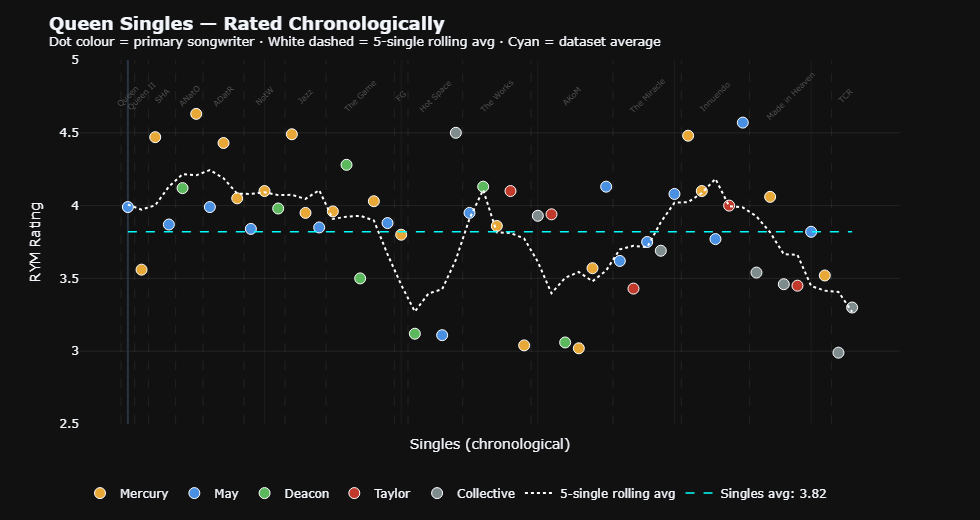


Singles: 54 total / 51 excl. Flash+Cosmos
Mean singles rating (all):      3.821
Mean singles rating (filtered): 3.847

Top 10 rated singles:
                      Song                Album  Rating             Songwriter
         Bohemian Rhapsody A Night at the Opera    4.63                Mercury
       The Show Must Go On             Innuendo    4.57            Queen [May]
            Under Pressure            Hot Space    4.50            Queen/Bowie
         Don't Stop Me Now                 Jazz    4.49                Mercury
                  Innuendo             Innuendo    4.48 Queen [Mercury/Taylor]
              Killer Queen   Sheer Heart Attack    4.47                Mercury
          Somebody to Love   A Day at the Races    4.43                Mercury
Another One Bites the Dust             The Game    4.28                 Deacon
      I Want to Break Free            The Works    4.13                 Deacon
 Who Wants to Live Forever      A Kind of Magic    4.13             

In [23]:
# ── Chart 8: Singles — Rated Over Time ───────────────────────────────────────
def c8_traces(df_s, show):
    df_sing = df_s[df_s['is_single']].copy().sort_values('album_rank')
    df_sing['global_idx'] = range(len(df_sing))
    traces = []

    for writer in MAIN_WRITERS:
        sub = df_sing[df_sing['main_writer'] == writer]
        if sub.empty: continue
        col = WRITER_COLOURS[writer]
        traces.append(go.Scatter(
            x=sub['global_idx'], y=sub['Rating'],
            mode='markers', name=writer,
            visible=show, showlegend=True, legendgroup=writer,
            marker=dict(size=11, color=col, line=dict(width=1, color='white')),
            customdata=sub[['Song','Album','Rating','Songwriter']].values,
            hovertemplate=(
                '<b>%{customdata[0]}</b><br>%{customdata[1]}<br>'
                'Rating: <b>%{customdata[2]:.2f}</b><br>'
                'Writer: %{customdata[3]}<extra></extra>'
            )
        ))

    sub_other = df_sing[~df_sing['main_writer'].isin(MAIN_WRITERS)]
    if not sub_other.empty:
        traces.append(go.Scatter(
            x=sub_other['global_idx'], y=sub_other['Rating'],
            mode='markers', name='Collective',
            visible=show, showlegend=True, legendgroup='Collective',
            marker=dict(size=11, color=WRITER_COLOURS['Other/Collective'],
                        line=dict(width=1, color='white')),
            customdata=sub_other[['Song','Album','Rating','Songwriter']].values,
            hovertemplate=(
                '<b>%{customdata[0]}</b><br>%{customdata[1]}<br>'
                'Rating: <b>%{customdata[2]:.2f}</b><br>'
                'Writer: %{customdata[3]}<extra></extra>'
            )
        ))

    # Rolling average as a trace so it updates with the toggle
    roll = (df_sing.set_index('global_idx')['Rating']
            .rolling(5, center=True, min_periods=2).mean())
    traces.append(go.Scatter(
        x=roll.index, y=roll.values,
        mode='lines', name='5-single rolling avg',
        visible=show, showlegend=True, legendgroup='rolling',
        line=dict(color='white', width=2, dash='dot'),
        hoverinfo='skip'
    ))

    # Average line as a trace so it recalculates per dataset
    avg = df_sing['Rating'].mean()
    traces.append(go.Scatter(
        x=[df_sing['global_idx'].min(), df_sing['global_idx'].max()],
        y=[avg, avg],
        mode='lines',
        name=f'Singles avg: {avg:.2f}',
        visible=show, showlegend=True, legendgroup='avg',
        line=dict(color='cyan', width=1.5, dash='dash'),
        hovertemplate=f'Singles avg: {avg:.2f}<extra></extra>'
    ))

    return traces, df_sing

N_C8_ALL  = 0
N_C8_FILT = 0

fig8 = go.Figure()
traces_all,  df_sing_all  = c8_traces(df_songs,      True)
traces_filt, df_sing_filt = c8_traces(df_songs_filt, False)
N_C8_ALL  = len(traces_all)
N_C8_FILT = len(traces_filt)
for t in traces_all:  fig8.add_trace(t)
for t in traces_filt: fig8.add_trace(t)

for album in album_order:
    sub = df_sing_all[df_sing_all['Album'] == album]
    if sub.empty: continue
    x0 = sub['global_idx'].min() - 0.5
    fig8.add_vline(x=x0,
        line=dict(color='rgba(255,255,255,0.08)', dash='dash', width=1))
    fig8.add_annotation(
        x=sub['global_idx'].mean(), y=4.75,
        text=album.replace('A Night at the Opera','ANatO')
                  .replace('A Day at the Races','ADatR')
                  .replace('News of the World','NotW')
                  .replace('Sheer Heart Attack','SHA')
                  .replace('A Kind of Magic','AKoM')
                  .replace('The Cosmos Rocks','TCR')
                  .replace('Flash Gordon','FG'),
        showarrow=False,
        font=dict(size=8, color='#555'),
        textangle=-45
    )

fig8.update_layout(
    title=dict(
        text='<b>Queen Singles \u2014 Rated Chronologically</b><br>'
             '<sup>Dot colour = primary songwriter \u00b7 White dashed = 5-single rolling avg \u00b7 Cyan = dataset average</sup>',
        font_size=18),
    xaxis=dict(title='Singles (chronological)',
               showticklabels=False,
               gridcolor='rgba(255,255,255,0.05)'),
    yaxis=dict(title='RYM Rating', range=[2.5, 5.0],
               gridcolor='rgba(255,255,255,0.08)'),
    template='plotly_dark', height=520,
    legend=dict(orientation='h', y=-0.15, x=0),
    margin=dict(t=60, b=80),
)
fig8.show()

print(f"\nSingles: {len(df_sing_all)} total / {len(df_sing_filt)} excl. Flash+Cosmos")
print(f"Mean singles rating (all):      {df_sing_all['Rating'].mean():.3f}")
print(f"Mean singles rating (filtered): {df_sing_filt['Rating'].mean():.3f}")
print(f"\nTop 10 rated singles:")
print(df_sing_all.nlargest(10,'Rating')[['Song','Album','Rating','Songwriter']].to_string(index=False))


## 🎵 Spotify Popularity

In [ ]:
# ── Spotify Popularity Scores ─────────────────────────────────────────────────
import time, re
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from tqdm.notebook import tqdm

SPOTIFY_CLIENT_ID     = '1c1e218c2c9f4cfc8cb3e81a0b217a86'
SPOTIFY_CLIENT_SECRET = 'fc4006d52ec1490aab82e7fe6642a730'

sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id=SPOTIFY_CLIENT_ID,
    client_secret=SPOTIFY_CLIENT_SECRET
))
print("\u2713 Spotify connected")

pop_map = {}
print("Fetching popularity scores (search + fetch by ID)...")
for _, row in tqdm(df_songs.iterrows(), total=len(df_songs)):
    try:
        clean  = re.sub(r'[\'\"()\[\]!?]', '', str(row['Song'])).strip()
        artist = 'Queen Paul Rodgers' if 'Cosmos' in str(row['Album']) else 'Queen'
        query  = f'track:{clean} artist:{artist}'
        results = sp.search(q=query, type='track', limit=1, market='GB')
        items   = results['tracks']['items']
        if not items: continue
        full = sp.track(items[0]['id'], market='GB')
        pop  = full.get('popularity')
        if pop is not None:
            pop_map[(row['Album'], row['Song'])] = pop
        time.sleep(0.15)
    except Exception:
        pass

df_songs['spotify_pop'] = df_songs.apply(
    lambda r: pop_map.get((r['Album'], r['Song'])), axis=1)
df_sp = df_songs.dropna(subset=['spotify_pop']).copy()
print(f"\u2713 Got scores for {len(df_sp)} / {len(df_songs)} songs")

fig_sp = go.Figure()
for writer in MAIN_WRITERS:
    sub = df_sp[df_sp['main_writer'] == writer]
    if sub.empty: continue
    fig_sp.add_trace(go.Scatter(
        x=sub['Rating'], y=sub['spotify_pop'],
        mode='markers', name=writer,
        marker=dict(size=9, color=WRITER_COLOURS[writer],
                    line=dict(width=0.5, color='white')),
        customdata=sub[['Song','Album','Songwriter']].values,
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>%{customdata[1]}<br>'
            'RYM: %{x:.2f} \u00b7 Spotify pop: %{y}<extra></extra>'
        )
    ))
fig_sp.update_layout(
    title=dict(text='<b>RYM Rating vs Spotify Popularity</b><br>'
               '<sup>Are the critically rated songs also the most streamed?</sup>',
               font_size=18),
    xaxis_title='RYM Rating', yaxis_title='Spotify Popularity (0\u2013100)',
    template='plotly_dark', height=520,
    legend=dict(orientation='h', y=-0.18)
)
fig_sp.show()


## 💾 Export HTML

In [24]:
# ── Export: Standalone HTML Report ───────────────────────────────────────────
import plotly as _pm

_js_path = os.path.join(os.path.dirname(_pm.__file__), 'package_data', 'plotly.min.js')
try:
    with open(_js_path, encoding='utf-8') as _f:
        _plotly_js = f'<script>{_f.read()}</script>'
except Exception:
    _plotly_js = '<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>'
    print("\u26a0 Using CDN for Plotly JS")

best  = df_songs.loc[df_songs["Rating"].idxmax()]
worst = df_songs.loc[df_songs["Rating"].idxmin()]
top20 = df_songs.nlargest(20,"Rating")[["Song","Album","Songwriter","Rating"]].copy()
top20["Rating"] = top20["Rating"].map("{:.2f}".format)
top20.columns   = ["Song","Album","Writer","Rating"]

# Inject trace counts for JS toggle
_nc = (f'var N_C1={N_C1},N_C2={N_C2},N_C2F={N_C2F},'
       f'N_C3={N_C3},N_C4={N_C4},N_C5={N_C5},'
       f'N_C6={N_C6},N_C7={N_C7},'
       f'N_C8_ALL={N_C8_ALL},N_C8_FILT={N_C8_FILT};')

TOGGLE_JS = f"""
<script>
{_nc}
var _fc_excluded = false;
function toggleFC() {{
    _fc_excluded = !_fc_excluded;
    var btn = document.getElementById('btn-fc');
    btn.textContent = '\u26a1 Flash/Cosmos: ' + (_fc_excluded ? 'OUT' : 'IN');
    btn.classList.toggle('active', _fc_excluded);
    var charts = [
        {{id:'queen-c1', na:N_C1,  nf:N_C1}},
        {{id:'queen-c2', na:N_C2,  nf:N_C2F}},
        {{id:'queen-c3', na:N_C3,  nf:N_C3}},
        {{id:'queen-c4', na:N_C4,  nf:N_C4}},
        {{id:'queen-c5', na:N_C5,  nf:N_C5}},
        {{id:'queen-c6', na:N_C6,  nf:N_C6}},
        {{id:'queen-c7', na:N_C7,  nf:N_C7}},
        {{id:'queen-c8', na:N_C8_ALL, nf:N_C8_FILT}},
    ];
    charts.forEach(function(c) {{
        var el = document.getElementById(c.id);
        if (!el || !el.data) return;
        var vis = [];
        for (var i=0; i<c.na; i++) vis.push(!_fc_excluded);
        for (var i=0; i<c.nf; i++) vis.push(_fc_excluded);
        Plotly.restyle(c.id, {{visible: vis}});
    }});
}}
window.addEventListener('load', function() {{
    document.getElementById('btn-fc').classList.add('active');
}});
</script>
"""

CSS = """
*{box-sizing:border-box;margin:0;padding:0}
body{background:#0d1117;color:#e6edf3;font-family:'Segoe UI',system-ui,sans-serif;
     padding:24px 20px;padding-top:80px}
h1{color:#E8A838;font-size:1.9em;border-bottom:2px solid #21262d;
   padding-bottom:14px;margin-bottom:24px}
h2{color:#79c0ff;font-size:1.2em;margin:40px 0 12px}
.sticky{position:fixed;top:0;left:0;right:0;z-index:9999;
        background:#161b22;border-bottom:2px solid #30363d;
        padding:10px 20px;display:flex;align-items:center;gap:12px;flex-wrap:wrap}
.sticky-label{color:#8b949e;font-size:.82em;font-weight:600}
.tbtn{padding:5px 14px;border-radius:6px;border:1px solid #444;cursor:pointer;
      font-size:.82em;font-weight:600;transition:all .15s;
      background:#1a1a1a;color:#e6edf3}
.tbtn:hover{background:#2a2a2a}
.tbtn.active{background:#E8A838;color:#0d1117;border-color:#E8A838}
.grid{display:grid;grid-template-columns:repeat(auto-fill,minmax(175px,1fr));
      gap:14px;margin-bottom:32px}
.card{background:#161b22;border:1px solid #30363d;border-radius:10px;
      padding:18px;text-align:center}
.val{font-size:1.9em;font-weight:700;color:#E8A838}
.lbl{font-size:.82em;color:#8b949e;margin-top:6px;line-height:1.35}
.chart-wrap{margin:20px 0;border:1px solid #30363d;border-radius:10px;overflow:hidden}
table{width:100%;border-collapse:collapse;font-size:.88em;margin-top:8px}
th{background:#161b22;color:#8b949e;padding:9px 14px;text-align:left;
   border-bottom:1px solid #30363d;font-weight:600}
td{padding:8px 14px;border-bottom:1px solid #21262d}
tr:hover td{background:#1c2128}
footer{margin-top:60px;padding-top:18px;border-top:1px solid #21262d;
       color:#8b949e;font-size:.78em;text-align:center}
"""

STICKY = """
<div class="sticky">
  <span class="sticky-label">All charts:</span>
  <button id="btn-fc" class="tbtn" onclick="toggleFC()">&#9889; Flash/Cosmos: IN</button>
  <span class="sticky-label" style="margin-left:auto;color:#444;font-size:.75em">
    Queen Discography Analytics
  </span>
</div>
"""

html = (
    "<!DOCTYPE html>\n<html lang=\"en\">\n<head>\n"
    "<meta charset=\"UTF-8\"><meta name=\"viewport\" content=\"width=device-width,initial-scale=1\">\n"
    "<title>Queen Discography Analytics</title>\n"
    + _plotly_js + "\n"
    + f"<style>{CSS}</style>\n"
    + TOGGLE_JS
    + "</head>\n<body>\n"
    + STICKY
    + "<h1>\U0001f3b8 Queen Discography Analytics</h1>\n"
    + f'''<div class="grid">
  <div class="card"><div class="val">{len(df_albums)}</div><div class="lbl">Albums</div></div>
  <div class="card"><div class="val">{len(df_songs)}</div><div class="lbl">Songs</div></div>
  <div class="card"><div class="val">{df_songs["Rating"].mean():.3f}</div><div class="lbl">Mean Rating<br><small>(all, out of 5.0)</small></div></div>
  <div class="card"><div class="val">{df_songs_filt["Rating"].mean():.3f}</div><div class="lbl">Mean Rating<br><small>(excl. Flash/Cosmos)</small></div></div>
  <div class="card"><div class="val">{best["Rating"]:.2f}</div>
    <div class="lbl">Highest Rated<br><small>{best["Song"]}</small></div></div>
</div>
'''
)

div_ids = ['queen-c1','queen-c2','queen-c3','queen-c4','queen-c5','queen-c6','queen-c7','queen-c8']
all_figs = [fig1, fig2, fig3, fig4, fig5, fig6, fig7, fig8]
try:
    if fig_sp is not None:
        all_figs.append(fig_sp)
        div_ids.append('queen-sp')
except NameError:
    pass

import copy
for fig, div_id in zip(all_figs, div_ids):
    fig_clean = copy.deepcopy(fig)
    fig_clean.update_layout(updatemenus=[])
    html += (f'<div class="chart-wrap">' +
             to_html(fig_clean, full_html=False, include_plotlyjs=False, div_id=div_id) +
             '</div>\n')

html += (
    "<h2>\U0001f3c6 Top 20 Rated Songs</h2>"
    + top20.to_html(index=False, border=0, classes="")
    + "\n<footer>Generated with Python \u00b7 RYM Data \u00b7 Plotly \u00b7 with data from Rate Your Music</footer>\n</body>\n</html>"
)

report_path = "queen_analytics.html"
with open(report_path, "w", encoding="utf-8") as fh:
    fh.write(html)
print(f"\u2713 Saved \u2192 {report_path}  ({os.path.getsize(report_path)/1024/1024:.1f} MB)")


✓ Saved → queen_analytics.html  (4.8 MB)
